# BME 574 — building a neural network from scratch
### 80-minute live demo · Project 3, Lecture 2 of 2

**Dataset:** cardiotocography — 2126 fetal heart-rate recordings, 21 features computed from the
trace, labelled Normal / Suspect / Pathologic by three obstetricians.

**What we build:** a dense network, forward and backward, in NumPy. No deep-learning library until
the last ten minutes, and then only to check our answer.

**What you need:** `numpy`, `matplotlib`, `scikit-learn`, `pandas`, and `data/fetal_health_ctg.csv`
next to this notebook. Nothing else. Every cell runs in under two seconds.

| | Time | Part |
|---|---|---|
| 0 | 0:00 | The data, and the bar we have to clear |
| 1 | 0:10 | Forward pass |
| 2 | 0:24 | Backward pass — and the gradient check |
| 3 | 0:40 | The training loop |
| 4 | 0:52 | Two ways to break it, on purpose |
| 5 | 1:04 | Overfitting, live |
| 6 | 1:14 | Does a real library agree with us? |

> **Instructor note.** Cells marked **▶ TYPE THIS LIVE** are worth writing out in front of the
> room — they are short and they are the ideas. Everything else is scaffolding: run it and talk
> over it. Prompts marked **Ask the room** are placed where a pause pays off; the expected answer
> follows in the cell output or the next markdown cell.

---
# 0 · The data, and the bar we have to clear
**0:00 – 0:10**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(0)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv('data/fetal_health_ctg.csv')
X_all = df.drop(columns='fetal_health').to_numpy(float)
y_all = df['fetal_health'].to_numpy(int) - 1          # -> 0, 1, 2
FEATURES = df.columns[:-1].tolist()
CLASSES = ['Normal', 'Suspect', 'Pathologic']

print('X', X_all.shape, '   y', y_all.shape)
print('class counts   ', np.bincount(y_all), '  ->', CLASSES)
print('majority class ', np.bincount(y_all).max() / len(y_all))
df.head(3).iloc[:, :6]

X (2126, 21)    y (2126,)
class counts    [1655  295  176]   -> ['Normal', 'Suspect', 'Pathologic']
majority class  0.7784571966133584


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations
0,120.0,0.000,0.0,0.000,0.000,0.0
1,132.0,0.006,0.0,0.006,0.003,0.0
2,133.0,0.003,0.0,0.008,0.003,0.0


**Ask the room:** *a classifier that ignores its input entirely and always says "Normal" — what
accuracy does it get?*

0.778. Write it on the board. Every number for the rest of the hour gets compared to it, and a
model that scores 0.80 on this data has learned essentially nothing.

In [2]:
# the features live on wildly different scales - this matters enormously in Part 4
s = X_all.std(axis=0)
for i in np.argsort(s)[[0, 1, -2, -1]]:
    print('%-56s std = %12.5f' % (FEATURES[i], s[i]))
print()
print('ratio largest/smallest std: %.0f' % (s.max() / s.min()))

severe_decelerations                                     std =      0.00006
prolongued_decelerations                                 std =      0.00059
histogram_min                                            std =     29.55326
histogram_width                                          std =     38.94653

ratio largest/smallest std: 679857


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)

# THE RULE FROM PROJECT 1: the scaler is a model parameter. Fit it on training rows only.
scaler = StandardScaler().fit(Xtr_raw)
Xtr, Xte = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)

print('train', Xtr.shape, '  test', Xte.shape)
print('train class counts', np.bincount(ytr), '   test', np.bincount(yte))
print()
print('training mean (first 4 features)', Xtr.mean(0)[:4], ' <- 0 by construction')
print('TEST     mean (first 4 features)', Xte.mean(0)[:4], ' <- NOT 0, and that is correct')

train (1594, 21)   test (532, 21)
train class counts [1241  221  132]    test [414  74  44]

training mean (first 4 features) [0. 0. 0. 0.]  <- 0 by construction
TEST     mean (first 4 features) [-0.0976 -0.0357  0.0336  0.0439]  <- NOT 0, and that is correct


That last line is worth ten seconds. The test set's mean is not zero, because we did not let it
influence the scaler. If it *were* exactly zero, we would have leaked.

Now the bar. Two baselines, both one line.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# The strongest model whose decision boundary is a straight cut. (It is multinomial
# logistic regression; we have not covered it yet, so treat it here purely as the
# best "straight cuts only" baseline - the left panel of the lecture's boundary figure.)
majority = float((yte == 0).mean())
linear_baseline = LogisticRegression(max_iter=5000).fit(Xtr, ytr)
pred_lr = linear_baseline.predict(Xte)

print('always predict Normal            accuracy %.3f' % majority)
print('best straight-boundary model     accuracy %.3f   macro-F1 %.3f'
      % ((pred_lr == yte).mean(), f1_score(yte, pred_lr, average='macro')))
print()
print('Anything we build has to beat 0.889, not 0.778.')

always predict Normal            accuracy 0.778
best straight-boundary model     accuracy 0.889   macro-F1 0.790

Anything we build has to beat 0.889, not 0.778.


---
# 1 · Forward pass
**0:10 – 0:24**

Three functions and we have a network. Architecture: **21 → 32 → 3**.

### ▶ TYPE THIS LIVE — initialisation

Two things to say while typing:

- Weights are random, biases are zero. If every weight started at the same value, every unit in a
  layer would compute the same thing and receive the same gradient forever — they would never
  differentiate. Symmetry has to be broken by the initialisation.
- The `sqrt(2 / fan_in)` is He initialisation (He et al. 2015), and the 2 is there because ReLU
  discards half its inputs. Too large and the activations explode through the layers; too small
  and they vanish. This one line is the difference between a network that trains and one that
  sits there.

In [5]:
def init_params(sizes, seed=0, out_scale=1.0):
    # sizes = [21, 32, 3]  ->  a list of [W, b] per layer
    r = np.random.default_rng(seed)
    params = []
    last = len(sizes) - 2
    for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
        sd = np.sqrt(2.0 / n_in) * (out_scale if i == last else 1.0)
        W = r.normal(0.0, sd, size=(n_in, n_out))
        b = np.zeros(n_out)
        params.append([W, b])
    return params


params = init_params([21, 32, 3])                 # out_scale=1.0 for now - see below
for i, (W, b) in enumerate(params):
    print('layer %d:  W %s   b %s' % (i + 1, W.shape, b.shape))
print()
print('total parameters:', sum(W.size + b.size for W, b in params))

layer 1:  W (21, 32)   b (32,)
layer 2:  W (32, 3)   b (3,)

total parameters: 803


### ▶ TYPE THIS LIVE — forward

`activations[0]` is the input, `activations[-1]` is the logits. We keep **every** intermediate
value, because the backward pass will need them — that is the memory cost of training.

In [6]:
def forward(params, X):
    # returns every activation; the last entry is the logits (no activation applied)
    activations = [X]
    last = len(params) - 1
    for i, (W, b) in enumerate(params):
        Z = activations[-1] @ W + b
        activations.append(Z if i == last else np.maximum(Z, 0.0))   # ReLU, except at the output
    return activations


def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)      # subtract the max: exp() cannot overflow.
    E = np.exp(Z)                             # only DIFFERENCES of logits matter, so this is free
    return E / E.sum(axis=1, keepdims=True)


def onehot(y, n_classes=3):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y


def cross_entropy(logits, Y):
    P = softmax(logits)
    return -float((Y * np.log(P + 1e-12)).sum()) / len(Y)

### A prediction, before we run anything

**Ask the room:** *an untrained network has seen no data. What loss should it have?*

It should spread its probability roughly evenly over the three classes, so the loss should be about
$-\log(1/3) = 1.0986$. Get them to commit to that number out loud before you run the next cell.

In [7]:
Ytr = onehot(ytr)
logits0 = forward(params, Xtr)[-1]
P0 = softmax(logits0)

print('predicted probabilities for the first 3 training rows:')
print(P0[:3])
print()
print('loss at initialisation   %.4f' % cross_entropy(logits0, Ytr))
print('-log(1/3)                %.4f   <- what we predicted' % -np.log(1 / 3))
print()
print('average probability given to its own favourite class:  %.3f' % P0.max(1).mean())
print('(if it had no opinion at all this would be about 0.33)')

predicted probabilities for the first 3 training rows:
[[0.0881 0.0511 0.8607]
 [0.1405 0.4744 0.3851]
 [0.2316 0.2155 0.5529]]

loss at initialisation   2.2898
-log(1/3)                1.0986   <- what we predicted

average probability given to its own favourite class:  0.621
(if it had no opinion at all this would be about 0.33)


### The prediction was wrong. Good — find out why.

The loss is **2.29**, more than double what it should be, and the untrained network is already
assigning about 0.62 to a class it picked for no reason. It is not undecided. It is *confident,
and confidently wrong*, before it has seen a single label.

**Ask the room:** *where could that confidence possibly have come from?*

The initialisation. `sqrt(2 / n_in)` is He scaling, and the 2 is there to compensate for a ReLU
throwing away half of its inputs. The **output** layer is not followed by a ReLU — it is followed
by a softmax. Applying the same rule there makes the logits larger than they should be, and
softmax turns large logits into confident probabilities.

It is a one-character fix: shrink the last layer.

In [8]:
params = init_params([21, 32, 3], out_scale=0.1)       # <- the fix
logits0 = forward(params, Xtr)[-1]

print('loss at initialisation   %.4f' % cross_entropy(logits0, Ytr))
print('-log(1/3)                %.4f' % -np.log(1 / 3))
print('average top probability  %.3f   (was 0.62)' % softmax(logits0).max(1).mean())

loss at initialisation   1.1733
-log(1/3)                1.0986
average top probability  0.371   (was 0.62)


> **The habit to sell here.** This network trains to the same final accuracy either way — the bad
> initialisation only cost a few wasted epochs, and nobody would ever have noticed. In a deeper
> network the same mistake saturates the softmax, drives the gradient toward zero, and the model
> does not train at all. You would have spent an afternoon on the learning rate.
>
> The check cost nothing: *one number you could compute in your head, tested before training*.
> Ask them what the equivalent check is for a regression network. (Answer: the initial MSE should
> be about the variance of the targets.)

---
# 2 · Backward pass — and the gradient check
**0:24 – 0:40**

This is the part of the demo that matters. Everything else is plumbing.

From the lecture, two facts:

```
delta at the output       = P - Y                       (softmax + cross-entropy, combined)
gradient for a layer      = (input to that layer).T @ delta
delta for the layer below = (delta @ W.T) * (this layer was positive)
```

Four lines in a loop, regardless of depth.

### ▶ TYPE THIS LIVE — backward

Type it slowly. The two things to narrate:

- `D = (softmax(...) - Y) / N` — this is the whole reason we chose cross-entropy. There is no
  softmax Jacobian anywhere in this function. One subtraction.
- The transpose in `A[i].T @ D` is not a trick. `A[i]` is `(N, n_in)`, `D` is `(N, n_out)`, and
  `W` is `(n_in, n_out)`. Only one arrangement produces that shape. **The shapes decide it, every
  time** — say this, because it is the single most useful debugging habit in the whole course.

In [9]:
def backward(params, activations, Y):
    # gradients of the mean cross-entropy w.r.t. every W and b
    N = len(Y)
    grads = [None] * len(params)

    D = (softmax(activations[-1]) - Y) / N          # <- the punchline from the lecture

    for i in range(len(params) - 1, -1, -1):
        grads[i] = [activations[i].T @ D, D.sum(axis=0)]
        if i > 0:                                    # push the signal down one layer
            D = (D @ params[i][0].T) * (activations[i] > 0)
    return grads

### The gradient check

In Project 2 you validated a finite-difference Jacobian against an analytic one and got agreement
near `1e-5`. Here we do the reverse: we have an analytic gradient and we validate it against finite
differences.

$$\frac{\partial L}{\partial \theta_j} \approx \frac{L(\theta + \varepsilon e_j) - L(\theta - \varepsilon e_j)}{2\varepsilon}$$

**This is the only way to know backpropagation is right.** A wrong gradient does not raise an
exception — it trains to a worse answer, slowly, and looks like a bad hyperparameter. Expect
agreement near **1e-7**. Anything below `1e-5` is a pass; a genuinely wrong gradient does not give
you `1e-4`, it gives you something of order **1**, so this test is not delicate.

In [10]:
def gradient_check(params, X, Y, n_samples=25, eps=1e-5, seed=0):
    r = np.random.default_rng(seed)
    analytic = backward(params, forward(params, X), Y)
    worst, rows = 0.0, []

    for li in range(len(params)):
        for pi, nm in [(0, 'W'), (1, 'b')]:
            T = params[li][pi]
            errs = []
            for _ in range(n_samples):
                idx = tuple(r.integers(0, s) for s in T.shape)
                orig = T[idx]
                h = eps * max(abs(orig), 1.0)

                T[idx] = orig + h
                up = cross_entropy(forward(params, X)[-1], Y)
                T[idx] = orig - h
                dn = cross_entropy(forward(params, X)[-1], Y)
                T[idx] = orig                                  # ALWAYS put it back

                num = (up - dn) / (2 * h)
                ana = analytic[li][pi][idx]
                errs.append(abs(num - ana) / max(abs(num) + abs(ana), 1e-12))
            rows.append((li + 1, nm, max(errs)))
            worst = max(worst, max(errs))
    return worst, rows


worst, rows = gradient_check(init_params([21, 32, 3], out_scale=0.1), Xtr[:40], Ytr[:40])
for li, nm, e in rows:
    print('layer %d  %s   worst relative error  %.3e' % (li, nm, e))
print()
print('WORST OVERALL  %.3e' % worst)
print('PASS - backpropagation agrees with finite differences.' if worst < 1e-5
      else 'FAIL - do not train this. Find the bug first.')

layer 1  W   worst relative error  1.361e-07
layer 1  b   worst relative error  9.206e-09
layer 2  W   worst relative error  6.027e-09
layer 2  b   worst relative error  3.007e-11

WORST OVERALL  1.361e-07
PASS - backpropagation agrees with finite differences.


> **Instructor note — the most valuable 90 seconds in the demo.** Break it on purpose. Edit
> `backward` to drop the ReLU mask (`D = D @ params[i][0].T`, without the `* (activations[i] > 0)`)
> and re-run the check. The error jumps from ~1e-7 to **1.0** — seven orders of magnitude. Then
> put it back.
>
> The point to make: the broken version *still trains*, and still reaches perhaps 0.88. Nothing
> crashes. Without this check you would have shipped it. **Run the gradient check every single time
> you write a derivative by hand.**

---
# 3 · The training loop
**0:40 – 0:52**

Shuffle, cut into minibatches, step downhill. That is the whole optimiser.

In [11]:
def accuracy(params, X, y):
    return float((forward(params, X)[-1].argmax(1) == y).mean())


def train(sizes, X, y, Xv, yv, epochs=60, lr=0.05, batch=64, seed=0, l2=0.0, verbose=True):
    params = init_params(sizes, seed, out_scale=0.1)      # the fix from Part 1
    Y, Yv = onehot(y), onehot(yv)
    r = np.random.default_rng(seed + 100)
    history = []

    for ep in range(epochs):
        order = r.permutation(len(X))                      # reshuffle every epoch
        for start in range(0, len(X), batch):
            idx = order[start:start + batch]
            grads = backward(params, forward(params, X[idx]), Y[idx])
            for (W, b), (gW, gb) in zip(params, grads):
                W -= lr * (gW + l2 * W)                    # l2=0 here; used in Part 5
                b -= lr * gb

        history.append((cross_entropy(forward(params, X)[-1], Y),
                        cross_entropy(forward(params, Xv)[-1], Yv),
                        accuracy(params, X, y), accuracy(params, Xv, yv)))
        if verbose and (ep < 3 or (ep + 1) % 15 == 0):
            tr_l, te_l, tr_a, te_a = history[-1]
            print('epoch %3d   train loss %.4f  acc %.3f    |    test loss %.4f  acc %.3f'
                  % (ep + 1, tr_l, tr_a, te_l, te_a))
    return params, np.array(history)


net, hist = train([21, 32, 3], Xtr, ytr, Xte, yte, epochs=60)

epoch   1   train loss 0.5363  acc 0.799    |    test loss 0.5502  acc 0.806
epoch   2   train loss 0.4474  acc 0.829    |    test loss 0.4657  acc 0.821
epoch   3   train loss 0.4009  acc 0.859    |    test loss 0.4177  acc 0.865
epoch  15   train loss 0.2676  acc 0.899    |    test loss 0.2934  acc 0.897
epoch  30   train loss 0.2282  acc 0.904    |    test loss 0.2623  acc 0.904
epoch  45   train loss 0.2037  acc 0.913    |    test loss 0.2468  acc 0.908
epoch  60   train loss 0.1848  acc 0.922    |    test loss 0.2373  acc 0.917


In [12]:
from sklearn.metrics import f1_score

pred = forward(net, Xte)[-1].argmax(1)
print('always predict Normal          %.3f' % majority)
print('best straight-boundary model   %.3f' % (pred_lr == yte).mean())
print('our network, 21 -> 32 -> 3     %.3f      <- macro-F1 %.3f'
      % ((pred == yte).mean(), f1_score(yte, pred, average='macro')))

always predict Normal          0.778
best straight-boundary model   0.889
our network, 21 -> 32 -> 3     0.917      <- macro-F1 0.831


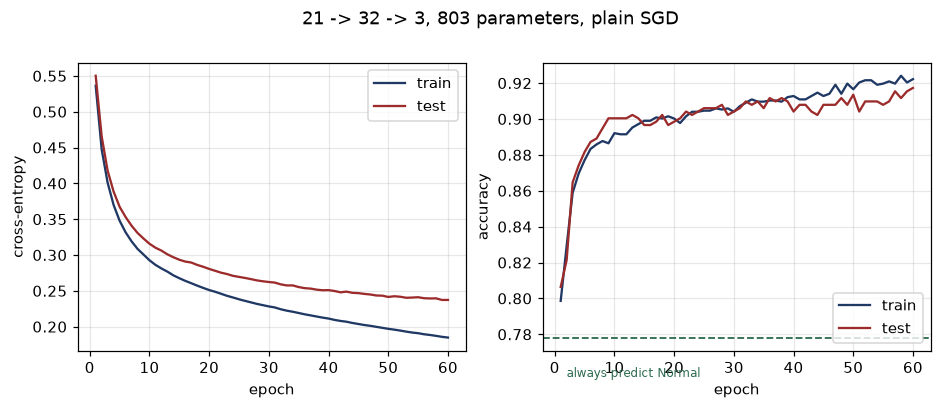

In [13]:
ep = np.arange(1, len(hist) + 1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(ep, hist[:, 0], color='#1F3864', label='train')
ax[0].plot(ep, hist[:, 1], color='#9C2B2B', label='test')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('cross-entropy'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, hist[:, 2], color='#1F3864', label='train')
ax[1].plot(ep, hist[:, 3], color='#9C2B2B', label='test')
ax[1].axhline(majority, color='#2E6B4F', ls='--', lw=1.2)
ax[1].text(2, majority - 0.022, 'always predict Normal', color='#2E6B4F', fontsize=8)
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy'); ax[1].legend(loc='lower right')
ax[1].grid(alpha=.3)
fig.suptitle('21 -> 32 -> 3, 803 parameters, plain SGD', y=1.02)
plt.show()

**Ask the room:** *the training and test curves are basically on top of each other here. Is that
good news or bad news?*

Both. It means this model is not overfitting — but it also means we are almost certainly leaving
capacity on the table. We will deliberately overfit in Part 5 to see what the other regime looks
like.

---
# 4 · Two ways to break it, on purpose
**0:52 – 1:04**

Both of these will happen to them in their own code. Showing the failure signature now saves hours
later.

### Failure 1 — forgetting to standardise

Same network, same everything, on the **raw** features. Recall the standard deviations differ by a
factor of ~680,000. Gradient descent takes one step size in every direction at once.

In [14]:
bad, hist_bad = train([21, 32, 3], Xtr_raw, ytr, Xte_raw, yte, epochs=60, verbose=False)

print('standardised features   test accuracy %.3f' % accuracy(net, Xte, yte))
print('raw features            test accuracy %.3f' % accuracy(bad, Xte_raw, yte))
print('majority baseline       test accuracy %.3f' % majority)
print()
print('training loss, first 6 epochs (raw):', np.round(hist_bad[:6, 0], 4))
print('training loss, first 6 epochs (std):', np.round(hist[:6, 0], 4))

standardised features   test accuracy 0.917
raw features            test accuracy 0.778
majority baseline       test accuracy 0.778

training loss, first 6 epochs (raw): [1.0242 0.745  0.7112 0.6928 0.6847 0.6806]
training loss, first 6 epochs (std): [0.5363 0.4474 0.4009 0.3699 0.348  0.3318]


Notice the failure signature: the loss does not diverge, it just *stalls*. Nothing errors. If you
had not run the standardised version first, you would conclude that neural networks do not work on
this problem — and a surprising number of published negative results are exactly this bug.

### Failure 2 — the learning rate

The one hyperparameter you cannot ignore. In Project 2, Levenberg–Marquardt adapted its own step
size through λ. Plain SGD does not: you choose, and you live with it.

In [15]:
print('%-8s %12s %10s   %s' % ('lr', 'final loss', 'test acc', ''))
for lr in [0.001, 0.01, 0.05, 0.5, 5.0, 50.0]:
    with np.errstate(over='ignore', invalid='ignore'):
        p_, h_ = train([21, 32, 3], Xtr, ytr, Xte, yte, epochs=30, lr=lr, verbose=False)
    loss, acc = h_[-1, 0], h_[-1, 3]
    if not np.isfinite(loss):
        note = '<- diverged to NaN: the steps overshot and blew up'
    elif lr <= 0.001:
        note = '<- still crawling; it would get there in a few thousand epochs'
    elif acc < majority + 0.02:
        note = '<- steps too big: bouncing around, never settles'
    else:
        note = ''
    print('%-8s %12.4f %10.3f   %s' % (lr, loss, acc, note))

lr         final loss   test acc   
0.001          0.6048      0.786   <- still crawling; it would get there in a few thousand epochs
0.01           0.3318      0.885   
0.05           0.2282      0.904   
0.5            0.1080      0.925   
5.0            0.4538      0.780   <- steps too big: bouncing around, never settles
50.0              nan      0.778   <- diverged to NaN: the steps overshot and blew up


**Ask the room:** *how would you choose the learning rate if you did not have the test labels?*

A validation split — and the answer they should give is that you never tune against the test set.
Every number in the table above was computed with test labels, which means this cell is a
demonstration, not a legitimate model-selection procedure. Say that explicitly; it is exactly the
mistake the lecture warned about, and doing it in front of them and *naming* it is more memorable
than forbidding it.

---
# 5 · Overfitting, live
**1:04 – 1:14**

To make a model overfit, starve it of data and give it far too many parameters. 200 training rows,
a 256–256 network — about 72,000 parameters for 200 examples.

In [16]:
sub = RNG.permutation(len(Xtr))[:200]
big, hb = train([21, 256, 256, 3], Xtr[sub], ytr[sub], Xte, yte,
                epochs=300, verbose=False)

best = int(hb[:, 1].argmin())
print('training loss      %.5f     training accuracy %.3f  <- memorised all 200'
      % (hb[-1, 0], hb[-1, 2]))
print()
print('test loss, best     %.4f   at epoch %d' % (hb[best, 1], best + 1))
print('test loss, final    %.4f   at epoch %d   (%.1f%% WORSE)'
      % (hb[-1, 1], len(hb), 100 * (hb[-1, 1] / hb[best, 1] - 1)))
print()
print('test accuracy, best  %.3f' % hb[best, 3])
print('test accuracy, final %.3f   <- essentially unchanged' % hb[-1, 3])

training loss      0.00521     training accuracy 1.000  <- memorised all 200

test loss, best     0.3444   at epoch 17
test loss, final    0.6043   at epoch 300   (75.4% WORSE)

test accuracy, best  0.883
test accuracy, final 0.889   <- essentially unchanged


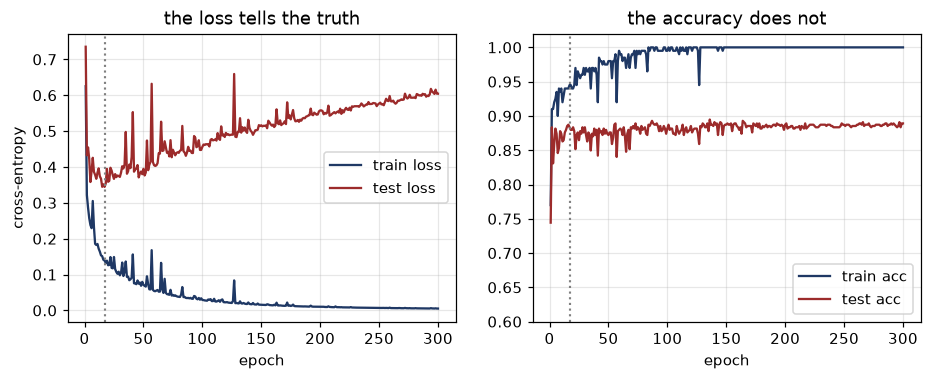

In [17]:
ep = np.arange(1, len(hb) + 1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(ep, hb[:, 0], color='#1F3864', label='train loss')
ax[0].plot(ep, hb[:, 1], color='#9C2B2B', label='test loss')
ax[0].axvline(best + 1, color='grey', ls=':', lw=1.4)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('cross-entropy'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_title('the loss tells the truth')
ax[1].plot(ep, hb[:, 2], color='#1F3864', label='train acc')
ax[1].plot(ep, hb[:, 3], color='#9C2B2B', label='test acc')
ax[1].axvline(best + 1, color='grey', ls=':', lw=1.4)
ax[1].set_ylim(0.6, 1.02); ax[1].set_xlabel('epoch'); ax[1].legend(loc='lower right')
ax[1].grid(alpha=.3); ax[1].set_title('the accuracy does not')
plt.show()

**This is the point of the whole lecture pair.**

The test *loss* got about 75% worse. The test *accuracy* did not budge. The network did not change
its answers — it became far more confident in them, including the wrong ones.

For a clinical model that is the dangerous failure, and accuracy cannot see it. A screening tool
that reports "94% confident: Normal" while being right 70% of the time is misleading the
clinician reading it, and every accuracy-based validation you could run would pass.

**Ask the room:** *if accuracy did not get worse, why stop early?* Let them argue before answering.

In [18]:
# the two standard fixes, on the same setting
_, h_l2 = train([21, 256, 256, 3], Xtr[sub], ytr[sub], Xte, yte,
                epochs=300, l2=1e-2, verbose=False)

print('%-26s %12s %12s' % ('', 'final loss', 'final acc'))
print('%-26s %12.4f %12.3f' % ('no regularisation', hb[-1, 1], hb[-1, 3]))
print('%-26s %12.4f %12.3f' % ('early stopping (ep %d)' % (best + 1), hb[best, 1], hb[best, 3]))
print('%-26s %12.4f %12.3f' % ('L2 = 1e-2, run to 300', h_l2[-1, 1], h_l2[-1, 3]))
print()
print('Both fix the calibration. Neither changes the accuracy much - because accuracy')
print('was never the thing that was broken.')

                             final loss    final acc
no regularisation                0.6043        0.889
early stopping (ep 17)           0.3444        0.883
L2 = 1e-2, run to 300            0.3619        0.893

Both fix the calibration. Neither changes the accuracy much - because accuracy
was never the thing that was broken.


---
# 6 · Does a real library agree with us?
**1:14 – 1:20**

Same architecture, same data, a completely independent implementation. If two independent
implementations of the same algorithm land in the same place, that is real evidence the
hand-written one is right — the same argument as the lmfit comparison in Project 2.

In [19]:
from sklearn.neural_network import MLPClassifier

skl = MLPClassifier(hidden_layer_sizes=(32,), activation='relu', solver='adam',
                    max_iter=1500, random_state=0).fit(Xtr, ytr)
pred_skl = skl.predict(Xte)

print('%-34s %10s %10s' % ('', 'accuracy', 'macro-F1'))
print('%-34s %10.3f %10.3f' % ('always predict Normal', majority,
                               f1_score(yte, np.zeros_like(yte), average='macro')))
print('%-34s %10.3f %10.3f' % ('best straight-boundary model',
                               (pred_lr == yte).mean(),
                               f1_score(yte, pred_lr, average='macro')))
print('%-34s %10.3f %10.3f' % ('our NumPy network', (pred == yte).mean(),
                               f1_score(yte, pred, average='macro')))
print('%-34s %10.3f %10.3f' % ('sklearn MLPClassifier', (pred_skl == yte).mean(),
                               f1_score(yte, pred_skl, average='macro')))
print()
print('About 40 lines of NumPy lands within a point of a mature library.')
print('The library gives you Adam, batch norm, dropout, GPUs and a maintainer -')
print('not a different algorithm.')

                                     accuracy   macro-F1
always predict Normal                   0.778      0.292
best straight-boundary model            0.889      0.790
our NumPy network                       0.917      0.831
sklearn MLPClassifier                   0.930      0.870

About 40 lines of NumPy lands within a point of a mature library.
The library gives you Adam, batch norm, dropout, GPUs and a maintainer -
not a different algorithm.


### The sting

One number is not a result. Break the accuracy out by class.

In [20]:
from sklearn.metrics import confusion_matrix, recall_score

cm = confusion_matrix(yte, pred)
print('overall accuracy %.3f' % (pred == yte).mean())
print()
print('%-14s %10s %10s' % ('class', 'n in test', 'recall'))
for c, nm in enumerate(CLASSES):
    print('%-14s %10d %10.3f'
          % (nm, (yte == c).sum(), recall_score(yte, pred, labels=[c], average='macro')))
print()
print('confusion matrix (rows = truth, columns = prediction)')
print(pd.DataFrame(cm, index=CLASSES, columns=CLASSES))

overall accuracy 0.917

class           n in test     recall
Normal                414      0.969
Suspect                74      0.716
Pathologic             44      0.773

confusion matrix (rows = truth, columns = prediction)
            Normal  Suspect  Pathologic
Normal         401       12           1
Suspect         15       53           6
Pathologic       4        6          34


The errors are not spread evenly. They are concentrated in the two classes that are the entire
reason the model exists: roughly **one Pathologic recording in four is called something else**.

A model that is excellent at recognising healthy fetuses and mediocre at recognising distressed
ones has its failure mode exactly backwards for its clinical purpose. And 0.917 overall accuracy
hides that completely.

In [21]:
# can we fix it? weight the cross-entropy by inverse class frequency.
counts = np.bincount(ytr)
weights = counts.sum() / (3 * counts)
print('class weights', np.round(weights, 2), '\n')


def backward_weighted(params, activations, Y, w):
    N = len(Y)
    grads = [None] * len(params)
    D = (softmax(activations[-1]) - Y) * (Y @ w)[:, None] / N     # <- the only change
    for i in range(len(params) - 1, -1, -1):
        grads[i] = [activations[i].T @ D, D.sum(axis=0)]
        if i > 0:
            D = (D @ params[i][0].T) * (activations[i] > 0)
    return grads


wp = init_params([21, 32, 3], 0, out_scale=0.1)
r = np.random.default_rng(100)
for _ in range(60):
    order = r.permutation(len(Xtr))
    for s0 in range(0, len(Xtr), 64):
        idx = order[s0:s0 + 64]
        for (W, b), (gW, gb) in zip(wp, backward_weighted(
                wp, forward(wp, Xtr[idx]), Ytr[idx], weights)):
            W -= 0.05 * gW
            b -= 0.05 * gb

pred_w = forward(wp, Xte)[-1].argmax(1)
print('%-24s %10s %10s %10s %10s' % ('', 'accuracy', 'Normal', 'Suspect', 'Patholog'))
for nm, pp in [('unweighted', pred), ('inverse-frequency', pred_w)]:
    rec = [recall_score(yte, pp, labels=[c], average='macro') for c in range(3)]
    print('%-24s %10.3f %10.3f %10.3f %10.3f' % (nm, (pp == yte).mean(), *rec))

class weights [0.43 2.4  4.03] 

                           accuracy     Normal    Suspect   Patholog
unweighted                    0.917      0.969      0.716      0.773
inverse-frequency             0.876      0.889      0.824      0.841


Pathologic recall rises from 0.77 to about 0.84, Suspect from 0.72 to about 0.82 — and overall
accuracy **falls** from 0.917 to about 0.88.

There is no setting of this model where you get both. Which trade you want is a clinical judgement
about the relative cost of a missed pathology versus a false alarm, and machine learning cannot
make it for you. That is where to end.

---

## What we built

- A dense network, forward and backward, in about 40 lines of NumPy
- A gradient check that proves the derivatives are right — and would have caught a bug that
  otherwise trains happily to a worse answer
- A training loop that beats the best straight-boundary model on real clinical data
- Two deliberate failures with recognisable signatures
- An overfitting run where the loss rotted by 75% while accuracy stood still
- Agreement with a mature library to within a point

Everything here generalises. A convolutional layer is a dense layer with weights reused across
positions; attention is a dense layer whose weights are computed from the input. The forward pass
remembers, the backward pass multiplies local derivatives in reverse. That does not change.

**Next:** automatic differentiation — how the backward pass gets written for you, for any
expression, without you deriving it by hand.